# 🎬 Single-Video Deepfake Predictor
**Full end-to-end pipeline — give it a raw `.mp4` / `.avi` / `.mov` and it handles everything:**

| Step | What happens |
|------|--------------|
| **Preprocessing** | Video → sample every N frames → MTCNN face detection → crop + resize to 224×224 |
| **Inference** | Extracted face frames → CNN-ViT-BiLSTM → P(real) / P(fake) |
| **Grad-CAM++** | Spatial heatmaps showing which face regions the model reacted to |
| **SLM caption** | Natural-language explanation of the verdict |

> Set your paths and backend in **Part 2 — Configuration**, then *Run All*.

## Part 0 — Install Dependencies

In [199]:
# Run once — facenet-pytorch provides MTCNN (same detector used in training)
# !pip install facenet-pytorch opencv-python timm

## Part 1 — Imports

In [200]:
import os
import shutil
import textwrap
import tempfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests

from PIL import Image
from tqdm.auto import tqdm
from facenet_pytorch import MTCNN

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import timm

warnings.filterwarnings("ignore")

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

PyTorch : 2.5.1+cu121
CUDA    : True
GPU     : NVIDIA GeForce RTX 3060


## Part 2 — Configuration
**Only edit this cell.**

In [ ]:
# ─────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────
MODEL_PATH = "../video_model.pth"        # path to your trained .pth
VIDEO_PATH = r"C:\Users\fatah.rahimi\Desktop\Models\02_27__hugging_happy__GVFLSZD5.mp4"   # raw video file (.mp4 / .avi / .mov / .mkv)

# ─────────────────────────────────────────────────
# PREPROCESSING  (must match training settings)
# ─────────────────────────────────────────────────
FRAME_SKIP   = 10    # sample 1 frame every N frames (same as training)
IMG_SIZE     = 224   # face crop resize target
MARGIN_RATIO = 0.25  # extra margin around detected face box

# ─────────────────────────────────────────────────
# INFERENCE
# ─────────────────────────────────────────────────
NUM_FRAMES = 32    # frames fed to model (must match training)
THRESHOLD  = 0.5   # P(real) >= THRESHOLD -> "real"

# ─────────────────────────────────────────────────
# MODEL ARCHITECTURE  (must match training)
# ─────────────────────────────────────────────────
CNN_MODEL   = "efficientnet_b0"
VIT_MODEL   = "deit_tiny_patch16_224"
PROJ_DIM    = 128
LSTM_HIDDEN = 128
LSTM_LAYERS = 1
DROPOUT     = 0.4194

# ─────────────────────────────────────────────────
# GRAD-CAM++
# ─────────────────────────────────────────────────
GRADCAM_N_FRAMES     = 4     # frames shown in the heatmap grid
GRADCAM_TARGET_CLASS = None  # None = predicted class | 0 = fake | 1 = real

# ─────────────────────────────────────────────────
# SLM CAPTION BACKEND
# ─────────────────────────────────────────────────
# Options: "ollama" | "anthropic"
SLM_BACKEND          = "ollama"
SLM_MAX_NEW_TOKENS   = 220
CAM_REGION_THRESHOLD = 0.6
SLM_TOP_K_FRAMES     = 3   # peak frames to report in caption

# Ollama (local server — run: ollama serve)
OLLAMA_MODEL = "phi3"
OLLAMA_URL   = "http://localhost:11434/api/generate"

# Anthropic — reads ANTHROPIC_API_KEY from environment
ANTHROPIC_MODEL = "claude-haiku-4-5-20251001"

## Part 3 — Device

In [202]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Part 4 — Video Preprocessing (MTCNN Face Extraction)
Replicates exactly the same pipeline used during dataset preparation:
- Sample 1 frame every `FRAME_SKIP` frames
- Detect face with MTCNN → expand bounding box by `MARGIN_RATIO`
- Crop face → resize to `IMG_SIZE × IMG_SIZE` → save as `.jpg`
- Frames land in a temp folder that is cleaned up after prediction

In [203]:
def is_video_file(path):
    return path.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))


def expand_box(x1, y1, x2, y2, frame_w, frame_h, margin_ratio=0.25):
    """Expand a face bounding box by margin_ratio on each side."""
    bw = x2 - x1
    bh = y2 - y1
    mx = int(bw * margin_ratio)
    my = int(bh * margin_ratio)
    x1 = max(0, x1 - mx)
    y1 = max(0, y1 - my)
    x2 = min(frame_w, x2 + mx)
    y2 = min(frame_h, y2 + my)
    return x1, y1, x2, y2


def extract_faces_from_video(
    video_path, save_dir, mtcnn,
    frame_skip=10, img_size=224, margin_ratio=0.25,
):
    """
    Extract face crops from a raw video file.

    Identical logic to the training preprocessing notebook:
      - read every `frame_skip`-th frame
      - detect the first/largest face with MTCNN
      - expand bounding box, crop, resize, save as JPEG

    Returns:
        int: number of face frames saved
    """
    os.makedirs(save_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    duration     = total_frames / fps if fps > 0 else 0
    print(f"  Video info : {total_frames} frames  |  {fps:.1f} fps  |  {duration:.1f}s")

    frame_id = 0
    saved_id = 0

    with tqdm(total=total_frames, desc="Extracting faces", unit="frame") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_id % frame_skip == 0:
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                boxes, _ = mtcnn.detect(rgb)

                if boxes is not None and len(boxes) > 0:
                    x1, y1, x2, y2 = map(int, boxes[0])  # first / largest face
                    h, w, _ = rgb.shape
                    x1, y1, x2, y2 = expand_box(x1, y1, x2, y2, w, h, margin_ratio)

                    face = rgb[y1:y2, x1:x2]
                    if face.size > 0:
                        face     = cv2.resize(face, (img_size, img_size))
                        out_path = os.path.join(save_dir, f"{saved_id:04d}.jpg")
                        cv2.imwrite(out_path, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
                        saved_id += 1

            frame_id += 1
            pbar.update(1)

    cap.release()
    return saved_id


print("Preprocessing functions ready.")

Preprocessing functions ready.


## Part 5 — Run Preprocessing

In [204]:
assert os.path.isfile(VIDEO_PATH) and is_video_file(VIDEO_PATH), \
    f"Not a valid video file: {VIDEO_PATH}"

video_name = os.path.splitext(os.path.basename(VIDEO_PATH))[0]

# MTCNN — same detector used during dataset creation
mtcnn = MTCNN(keep_all=False, device=device)

# Temporary directory for extracted face frames
tmp_frames_dir = tempfile.mkdtemp(prefix=f"deepfake_{video_name}_")
print(f"Temp frames dir : {tmp_frames_dir}")

n_saved = extract_faces_from_video(
    video_path   = VIDEO_PATH,
    save_dir     = tmp_frames_dir,
    mtcnn        = mtcnn,
    frame_skip   = FRAME_SKIP,
    img_size     = IMG_SIZE,
    margin_ratio = MARGIN_RATIO,
)

print(f"\n  Extracted {n_saved} face frames from '{video_name}'")

if n_saved == 0:
    raise RuntimeError(
        "No faces detected in the video.\n"
        "Try reducing FRAME_SKIP, or check that the video contains visible faces."
    )
if n_saved < NUM_FRAMES:
    print(
        f"  Warning: only {n_saved} frames extracted but NUM_FRAMES={NUM_FRAMES}.\n"
        f"  Frames will be repeated via linspace sampling — consider lowering NUM_FRAMES."
    )

Temp frames dir : C:\Users\FATAH~1.RAH\AppData\Local\Temp\deepfake_02_27__hugging_happy__GVFLSZD5__gfctq2u
  Video info : 685 frames  |  24.0 fps  |  28.5s


Extracting faces: 100%|██████████| 685/685 [00:24<00:00, 28.05frame/s]


  Extracted 229 face frames from '02_27__hugging_happy__GVFLSZD5'


## Part 6 — Model Definition

In [205]:
class CNN_ViT_BiLSTM(nn.Module):
    """
    Hybrid CNN + ViT backbone with BiLSTM temporal aggregation.
    Binary classification: 0 = fake, 1 = real.
    """

    def __init__(self, cnn_model, vit_model, proj_dim, lstm_hidden, lstm_layers, dropout):
        super().__init__()

        self.cnn = timm.create_model(cnn_model, pretrained=False)
        self.cnn.reset_classifier(0)

        self.vit = timm.create_model(vit_model, pretrained=False)
        self.vit.reset_classifier(0)

        with torch.no_grad():
            dummy   = torch.randn(1, 3, 224, 224)
            cnn_dim = self.cnn(dummy).shape[1]
            vit_dim = self.vit(dummy).shape[1]

        self.cnn_proj    = nn.Sequential(nn.Linear(cnn_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.vit_proj    = nn.Sequential(nn.Linear(vit_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.fusion_norm = nn.LayerNorm(proj_dim * 2)

        self.lstm = nn.LSTM(
            input_size    = proj_dim * 2,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = 0.0 if lstm_layers == 1 else dropout,
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x           = x.view(B * T, C, H, W)
        cnn_feat    = self.cnn_proj(self.cnn(x))
        vit_feat    = self.vit_proj(self.vit(x))
        fused       = self.fusion_norm(torch.cat([cnn_feat, vit_feat], dim=1))
        seq_feat    = fused.view(B, T, -1)
        lstm_out, _ = self.lstm(seq_feat)
        return self.classifier(lstm_out.mean(dim=1))

## Part 7 — Load Trained Weights

In [206]:
model = CNN_ViT_BiLSTM(
    cnn_model   = CNN_MODEL,
    vit_model   = VIT_MODEL,
    proj_dim    = PROJ_DIM,
    lstm_hidden = LSTM_HIDDEN,
    lstm_layers = LSTM_LAYERS,
    dropout     = DROPOUT,
).to(device)

assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"Loaded : {MODEL_PATH}")
print(f"Params : {sum(p.numel() for p in model.parameters()):,}")

Loaded : ../video_model.pth
Params : 10,149,437


## Part 8 — Inference Transform & Frame Loader

Prediction uses **`val_test_transform`** — identical to the transform used on the
validation and test sets during training. No augmentation is applied:

| Transform | Train (`train_transform`) | Inference (`val_test_transform`) | Why |
|-----------|--------------------------|----------------------------------|-----|
| `Resize(224)` | ✅ | ✅ | Required by model |
| `RandomHorizontalFlip` | ✅ | ❌ | Augmentation only — would flip heatmaps |
| `RandomRotation(10)` | ✅ | ❌ | Augmentation only |
| `ColorJitter` | ✅ | ❌ | Augmentation only |
| `RandomJPEGCompression` | ✅ | ❌ | Robustness training only |
| `ToTensor` | ✅ | ✅ | Required |
| `Normalize(ImageNet)` | ✅ | ✅ | Must match training stats |

Frame sampling uses **uniform** (`np.linspace`) — matching `mode="uniform"` used
for `val_dataset` and `test_dataset` in training.

In [207]:
import io

# ─────────────────────────────────────────────────────────────────
# val_test_transform  — must be identical to training val/test transform
# No augmentation: RandomHorizontalFlip / RandomRotation /
#                  ColorJitter / RandomJPEGCompression are training-only.
# ─────────────────────────────────────────────────────────────────
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),          # same as training
    transforms.ToTensor(),
    transforms.Normalize(                   # ImageNet stats — same as training
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def denorm(tensor):
    """Undo ImageNet normalisation → [0, 1] clipped (for visualisation)."""
    return (tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)


def load_frames_from_folder(folder, num_frames):
    """
    Load `num_frames` face-crop frames from a folder using UNIFORM sampling.

    Matches VideoFrameDataset._sample_indices() with mode='uniform':
        indices = np.linspace(0, n_frames - 1, num_frames, dtype=int)

    If fewer frames were extracted than num_frames, linspace naturally
    repeats boundary frames — same behaviour as the dataset class.

    Returns:
        torch.Tensor: shape (T, C, H, W), float32, normalised.
    """
    IMG_EXTS = (".jpg", ".jpeg", ".png")
    files = sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(IMG_EXTS)
    ])
    assert files, f"No image files found in: {folder}"

    # Uniform sampling — mirrors val/test mode in VideoFrameDataset
    indices = np.linspace(0, len(files) - 1, num_frames, dtype=int)
    frames  = [inference_transform(Image.open(files[i]).convert("RGB")) for i in indices]
    return torch.stack(frames, dim=0)   # (T, C, H, W)


def overlay_cam(frame_tensor, cam):
    """Blend Grad-CAM++ heatmap onto a frame tensor → uint8 RGB (H, W, 3)."""
    rgb  = (denorm(frame_tensor.unsqueeze(0))[0].permute(1, 2, 0).numpy() * 255).astype("uint8")
    heat = cv2.cvtColor(
        cv2.applyColorMap((cam * 255).astype("uint8"), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB,
    )
    return (0.55 * rgb + 0.45 * heat).astype("uint8")


LABEL_MAP = {0: "fake", 1: "real"}
print("Inference transform  : val_test_transform (Resize → ToTensor → Normalize)")
print("Frame sampling mode  : uniform (np.linspace) — matches val/test VideoFrameDataset")


Inference transform  : val_test_transform (Resize → ToTensor → Normalize)
Frame sampling mode  : uniform (np.linspace) — matches val/test VideoFrameDataset


## Part 9 — Load Face Frames & Run Inference

In [208]:
# Load the face-crop frames extracted in Part 5
frames_tensor = load_frames_from_folder(tmp_frames_dir, NUM_FRAMES)  # (T, C, H, W)

model.eval()
with torch.no_grad():
    logit     = model(frames_tensor.unsqueeze(0).to(device))   # (1, 1)
    prob_real = torch.sigmoid(logit).item()

prob_fake  = 1.0 - prob_real
pred_class = int(prob_real >= THRESHOLD)    # 1 = real, 0 = fake
prediction = LABEL_MAP[pred_class]
confidence = round((prob_real if pred_class == 1 else prob_fake) * 100, 1)

sep = "=" * 55
print(sep)
print(f"  Video       : {video_name}")
print(f"  Frames used : {NUM_FRAMES} (from {n_saved} extracted)")
print(f"  Prediction  : {prediction.upper()}")
print(f"  Confidence  : {confidence}%")
print(f"  P(real)     : {prob_real:.4f}")
print(f"  P(fake)     : {prob_fake:.4f}")
print(sep)

  Video       : 02_27__hugging_happy__GVFLSZD5
  Frames used : 32 (from 229 extracted)
  Prediction  : FAKE
  Confidence  : 100.0%
  P(real)     : 0.0000
  P(fake)     : 1.0000


## Part 10 — Preview: Extracted Face Frames
Sanity-check strip — shows the raw face crops before any model processing.

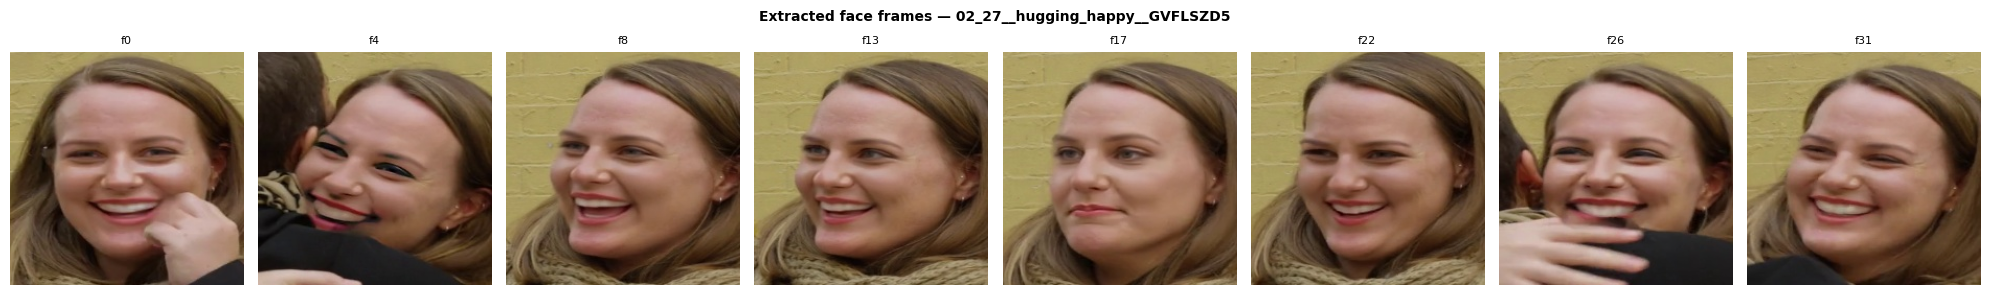

Saved: face_frames_preview.png


In [209]:
preview_idx = np.linspace(0, NUM_FRAMES - 1, min(8, NUM_FRAMES), dtype=int)

fig, axes = plt.subplots(1, len(preview_idx), figsize=(len(preview_idx) * 2.5, 3))
fig.suptitle(f"Extracted face frames — {video_name}", fontweight="bold", fontsize=10)

for ax, fi in zip(axes, preview_idx):
    rgb = denorm(frames_tensor[fi].unsqueeze(0))[0].permute(1, 2, 0).numpy()
    ax.imshow(rgb)
    ax.set_title(f"f{fi}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("face_frames_preview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: face_frames_preview.png")

## Part 11 — Grad-CAM++ Implementation

In [210]:
class GradCAMPlusPlus:
    """
    Grad-CAM++ for the CNN branch of CNN_ViT_BiLSTM.
    Hooks the activation tensor of model.cnn's last Conv2d.
    Works even when CNN backbone weights have requires_grad=False.
    """

    def __init__(self, model):
        self.model      = model
        self._features  = None
        self._gradients = None
        self._hooks     = []
        self._target    = self._find_last_conv(model.cnn)
        self._register()
        print(f"Grad-CAM++ target : {self._target.__class__.__name__}")

    @staticmethod
    def _find_last_conv(module):
        last = None
        for m in module.modules():
            if isinstance(m, nn.Conv2d):
                last = m
        if last is None:
            raise RuntimeError("No Conv2d found in model.cnn")
        return last

    def _register(self):
        def fwd_hook(module, inp, output):
            self._features = output
            def grad_hook(grad):
                self._gradients = grad
            self._hooks.append(output.register_hook(grad_hook))
        self._hooks.append(self._target.register_forward_hook(fwd_hook))

    def remove(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

    def generate(self, frames, target_class=None):
        """
        Compute per-frame Grad-CAM++ heatmaps.

        Args:
            frames       : (T, C, H, W) tensor on device.
            target_class : 0 | 1 | None (uses predicted class).

        Returns:
            cams         : np.ndarray (T, 224, 224) in [0, 1]
            prob_real    : float
            target_class : int
        """
        self._features = self._gradients = None
        x = frames.unsqueeze(0).detach().requires_grad_(True)

        self.model.eval()
        self.model.lstm.train()   # cuDNN LSTM backward requires train()
        try:
            logit     = self.model(x)
            prob_real = torch.sigmoid(logit).item()
            if target_class is None:
                target_class = int(prob_real >= 0.5)
            score = logit if target_class == 1 else -logit
            self.model.zero_grad()
            score.backward()
        finally:
            self.model.lstm.eval()

        assert self._gradients is not None, "Gradient hook did not fire."

        grads    = self._gradients.detach()    # (T, C, h, w)
        features = self._features.detach()     # (T, C, h, w)

        grads_sq  = grads ** 2
        grads_cub = grads ** 3
        denom     = 2 * grads_sq + features * grads_cub
        denom     = torch.where(denom != 0, denom, torch.ones_like(denom))
        alpha     = grads_sq / denom
        weights   = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)
        cams      = F.relu((weights * features).sum(dim=1))

        cams = F.interpolate(
            cams.unsqueeze(1), size=(224, 224), mode="bilinear", align_corners=False
        ).squeeze(1).cpu().numpy()

        for i in range(len(cams)):
            mn, mx = cams[i].min(), cams[i].max()
            cams[i] = (cams[i] - mn) / (mx - mn + 1e-8)

        return cams, prob_real, target_class


print("GradCAMPlusPlus ready.")

GradCAMPlusPlus ready.


## Part 12 — Run Grad-CAM++

Grad-CAM++ target : Conv2d


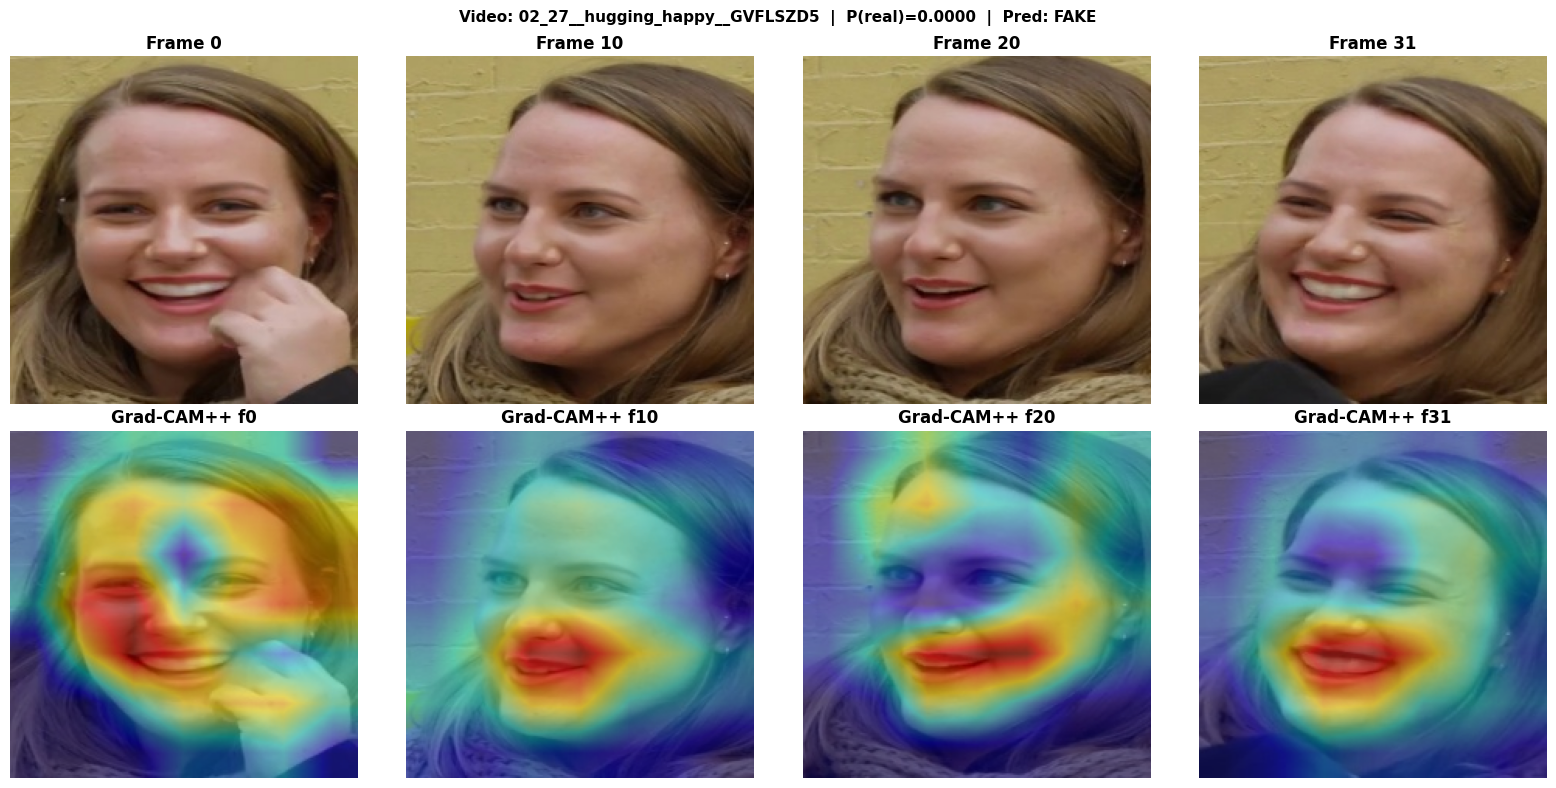

Saved: gradcam_result.png


In [211]:
gcpp = GradCAMPlusPlus(model)
cams, prob_real, pred_class = gcpp.generate(
    frames_tensor.to(device), target_class=GRADCAM_TARGET_CLASS
)
gcpp.remove()

display_frame_idx = np.linspace(0, NUM_FRAMES - 1, GRADCAM_N_FRAMES, dtype=int)

fig, axes = plt.subplots(2, GRADCAM_N_FRAMES, figsize=(4 * GRADCAM_N_FRAMES, 8))
fig.suptitle(
    f"Video: {video_name}  |  P(real)={prob_real:.4f}  |  Pred: {LABEL_MAP[pred_class].upper()}",
    fontsize=11, fontweight="bold"
)

for col, fi in enumerate(display_frame_idx):
    # Original face crop
    rgb = denorm(frames_tensor[fi].unsqueeze(0))[0].permute(1, 2, 0).numpy()
    axes[0, col].imshow(rgb)
    axes[0, col].set_title(f"Frame {fi}", fontweight="bold")
    axes[0, col].axis("off")

    # Grad-CAM++ overlay
    axes[1, col].imshow(overlay_cam(frames_tensor[fi], cams[fi]))
    axes[1, col].set_title(f"Grad-CAM++ f{fi}", fontweight="bold")
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("gradcam_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gradcam_result.png")

## Part 13 — Temporal Salience Strip
Shows which frames drove the decision most strongly across time.

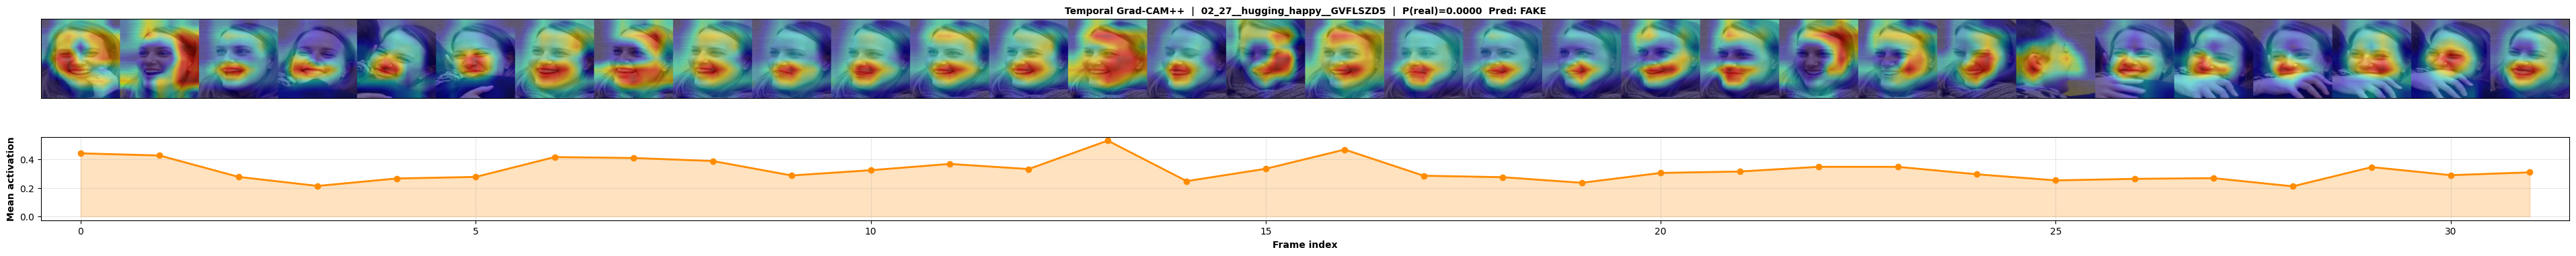

Saved: gradcam_temporal_strip.png


In [212]:
mean_activation = cams.mean(axis=(1, 2))   # (T,)

fig, (ax_strip, ax_line) = plt.subplots(
    2, 1, figsize=(NUM_FRAMES * 1.2, 5),
    gridspec_kw={"height_ratios": [3, 1]}
)

strip_img = np.concatenate(
    [overlay_cam(frames_tensor[i], cams[i]) for i in range(NUM_FRAMES)], axis=1
)
ax_strip.imshow(strip_img)
ax_strip.set_xticks([])
ax_strip.set_yticks([])
ax_strip.set_title(
    f"Temporal Grad-CAM++  |  {video_name}  |  "
    f"P(real)={prob_real:.4f}  Pred: {LABEL_MAP[pred_class].upper()}",
    fontweight="bold", fontsize=10
)

ax_line.plot(range(NUM_FRAMES), mean_activation, marker="o", linewidth=2, color="darkorange")
ax_line.fill_between(range(NUM_FRAMES), mean_activation, alpha=0.25, color="darkorange")
ax_line.set_xlim(-0.5, NUM_FRAMES - 0.5)
ax_line.set_xlabel("Frame index", fontweight="bold")
ax_line.set_ylabel("Mean activation", fontweight="bold")
ax_line.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gradcam_temporal_strip.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gradcam_temporal_strip.png")

## Part 14 — SLM Caption Setup

| Backend | Requirement |
|---------|-------------|
| `ollama` | `ollama serve` running locally |
| `anthropic` | `ANTHROPIC_API_KEY` set in environment |

In [213]:
def activation_region(cam, threshold=0.6):
    """Return a human-readable spatial description of the hottest CAM region."""
    mask = cam >= threshold
    rows, cols = np.where(mask)
    if len(rows) == 0:
        return "whole frame"
    cy = ((rows.min() + rows.max()) / 2) / cam.shape[0]
    cx = ((cols.min() + cols.max()) / 2) / cam.shape[1]
    v  = "upper" if cy < 0.4 else ("lower" if cy > 0.6 else "mid")
    h  = "left"  if cx < 0.4 else ("right" if cx > 0.6 else "center")
    return f"{v}-{h} area"


def extract_cam_signals(cams, top_k=3, threshold=0.6):
    """Return the top-k highest-activation frames and their spatial regions."""
    mean_act    = cams.mean(axis=(1, 2))
    peak_frames = np.argsort(mean_act)[::-1][:top_k].tolist()
    regions     = [activation_region(cams[i], threshold) for i in peak_frames]
    return peak_frames, regions, mean_act


def build_prompt(video_name, pred_class, prob_real, peak_frames, regions):
    label      = "FAKE" if pred_class == 0 else "REAL"
    conf       = round((prob_real if pred_class == 1 else 1 - prob_real) * 100, 1)
    frame_desc = ", ".join(f"frame {fi} ({reg})" for fi, reg in zip(peak_frames, regions))
    return (
        f"You are a deepfake detection analyst. Explain the following result "
        f"to a non-technical user in 3-4 clear sentences.\n\n"
        f"Video: {video_name}\n"
        f"Verdict: {label} with {conf}% confidence\n"
        f"Key evidence frames (highest Grad-CAM++ activation): {frame_desc}\n\n"
        f"Explain what the model likely detected, which facial regions triggered "
        f"the decision, and what this means for the video's authenticity. "
        f"Use plain English. No technical jargon."
    )


def call_ollama(prompt):
    payload = {
        "model" : OLLAMA_MODEL,
        "prompt": prompt,
        "stream": False,
        "options": {"num_predict": SLM_MAX_NEW_TOKENS, "temperature": 0.7},
    }
    resp = requests.post(OLLAMA_URL, json=payload, timeout=120)
    resp.raise_for_status()
    return resp.json()["response"].strip()


def call_anthropic(prompt):
    import anthropic
    client = anthropic.Anthropic()   # reads ANTHROPIC_API_KEY from env
    msg = client.messages.create(
        model      = ANTHROPIC_MODEL,
        max_tokens = SLM_MAX_NEW_TOKENS,
        messages   = [{"role": "user", "content": prompt}],
    )
    return msg.content[0].text.strip()


def generate_caption(prompt):
    if SLM_BACKEND == "anthropic":
        return call_anthropic(prompt)
    return call_ollama(prompt)


print(f"SLM backend : {SLM_BACKEND}")

SLM backend : ollama


## Part 15 — Generate SLM Caption

In [214]:
peak_frames, regions, mean_act = extract_cam_signals(
    cams, top_k=SLM_TOP_K_FRAMES, threshold=CAM_REGION_THRESHOLD
)

prompt = build_prompt(video_name, pred_class, prob_real, peak_frames, regions)

print("Generating caption...")
caption = generate_caption(prompt)

sep = "=" * 64
print(f"\n{sep}")
print(f"  Video      : {video_name}")
print(f"  Verdict    : {LABEL_MAP[pred_class].upper()}  P(real)={prob_real:.4f}")
print(f"  Peak frames: {peak_frames}")
print(f"  Regions    : {regions}")
print(f"\n  Caption:\n")
print(f"  {caption}")
print(sep)

Generating caption...

  Video      : 02_27__hugging_happy__GVFLSZD5
  Verdict    : FAKE  P(real)=0.0000
  Peak frames: [13, 16, 0]
  Regions    : ['mid-center area', 'mid-right area', 'mid-center area']

  Caption:

  The deepfake detection tool analyzed a hugging happy video and confidently determined that it was not real; we can be certain about its fake status because of how consistent the analysis is, at a level where there's no doubt or uncertainty whatsoever—100%. This means when looking closely in particular places on someone’th e face during specific moments captured by these frames (the mid-center and right areas), it strongly suggests that facial movements do not match natural behavior. In simpler terms, the video likely shows an artificially created or altered image of a person giving a fake hug because those parts of their face just don't look like they should when you see someone genuinely smiling with arms around another real human being in front of them.


## Part 16 — Final Visual: Peak Frames + Heatmap + SLM Caption

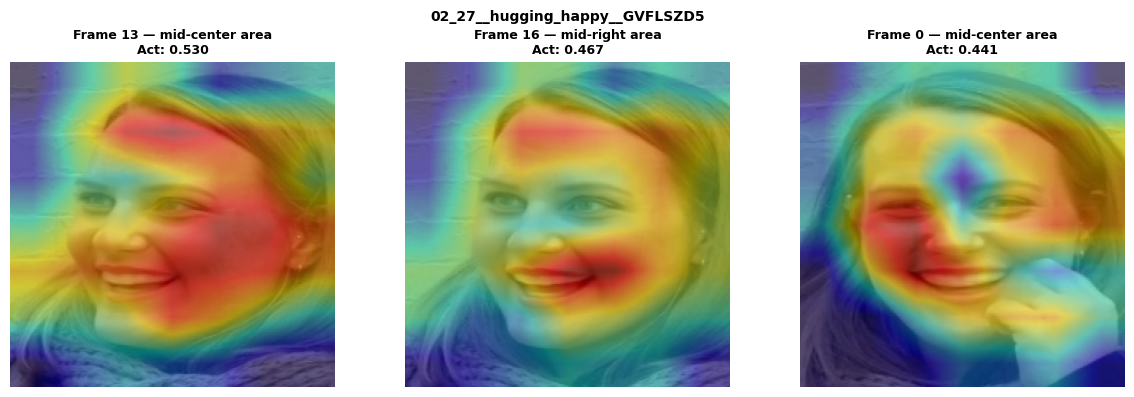


[FAKE  P(real)=0.0000]
The deepfake detection tool analyzed a hugging happy video and confidently determined that it was not real; we
can be certain about its fake status because of how consistent the analysis is, at a level where there's no
doubt or uncertainty whatsoever—100%. This means when looking closely in particular places on someone’th e
face during specific moments captured by these frames (the mid-center and right areas), it strongly suggests
that facial movements do not match natural behavior. In simpler terms, the video likely shows an artificially
created or altered image of a person giving a fake hug because those parts of their face just don't look like
they should when you see someone genuinely smiling with arms around another real human being in front of them.
Saved: explained_result.png


In [215]:
n_show = min(SLM_TOP_K_FRAMES, len(peak_frames))

# Create figure with only one row of image subplots (no caption subplot)
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 4, 4))
if n_show == 1:
    axes = [axes]  # make iterable if only one frame

for col, fi in enumerate(peak_frames[:n_show]):
    ax = axes[col]
    ax.imshow(overlay_cam(frames_tensor[fi], cams[fi]))
    ax.set_title(
        f"Frame {fi} — {regions[col]}\nAct: {mean_act[fi]:.3f}",
        fontsize=9, fontweight="bold"
    )
    ax.axis("off")

fig.suptitle(f"{video_name}", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig("explained_result.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the caption as plain text below the image (in console / notebook)
verdict = LABEL_MAP[pred_class].upper()
color_msg = "RED" if pred_class == 0 else "GREEN"   # optional visual cue
wrapped = "\n".join(textwrap.wrap(caption, width=110))
print(f"\n[{verdict}  P(real)={prob_real:.4f}]\n{wrapped}")
print("Saved: explained_result.png")

## Part 17 — Cleanup & Summary

In [216]:
# Remove temporary frame folder
shutil.rmtree(tmp_frames_dir, ignore_errors=True)
print(f"Temp folder removed: {tmp_frames_dir}")

outputs = [
    ("face_frames_preview.png",    "Sanity-check strip of extracted face crops"),
    ("gradcam_result.png",         "Original face crops + Grad-CAM++ overlays"),
    ("gradcam_temporal_strip.png", "Temporal salience strip + activation timeline"),
    ("explained_result.png",       "Peak frames + heatmap + SLM caption"),
]

sep = "=" * 55
print(f"\n{sep}")
print(f"  Video          : {video_name}")
print(f"  Frame skip     : 1 per {FRAME_SKIP} video frames")
print(f"  Faces extracted: {n_saved}")
print(f"  Frames to model: {NUM_FRAMES}")
print(f"  Prediction     : {LABEL_MAP[pred_class].upper()}")
print(f"  Confidence     : {confidence}%")
print(f"  P(real)        : {prob_real:.4f}")
print(f"  P(fake)        : {prob_fake:.4f}")
print(f"  Peak frames    : {peak_frames}")
print(f"  Regions        : {regions}")
print()
print("  Caption:")
for line in textwrap.wrap(caption, width=50):
    print(f"    {line}")
print()
print("  Output files:")
for fname, desc in outputs:
    exists = "ok" if os.path.exists(fname) else "  "
    print(f"    [{exists}] {fname:<37} {desc}")
print(sep)

Temp folder removed: C:\Users\FATAH~1.RAH\AppData\Local\Temp\deepfake_02_27__hugging_happy__GVFLSZD5__gfctq2u

  Video          : 02_27__hugging_happy__GVFLSZD5
  Frame skip     : 1 per 3 video frames
  Faces extracted: 229
  Frames to model: 32
  Prediction     : FAKE
  Confidence     : 100.0%
  P(real)        : 0.0000
  P(fake)        : 1.0000
  Peak frames    : [13, 16, 0]
  Regions        : ['mid-center area', 'mid-right area', 'mid-center area']

  Caption:
    The deepfake detection tool analyzed a hugging
    happy video and confidently determined that it was
    not real; we can be certain about its fake status
    because of how consistent the analysis is, at a
    level where there's no doubt or uncertainty
    whatsoever—100%. This means when looking closely
    in particular places on someone’th e face during
    specific moments captured by these frames (the
    mid-center and right areas), it strongly suggests
    that facial movements do not match natural
    behavior. I